การวิเคราะห์อารมณ์ข้อความภาษาไทย
Thai Sentiment Analysis


1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from pythainlp.tokenize import word_tokenize
from pythainlp.corpus.common import thai_stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

C:\Users\LOQ\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2. Load Dataset

In [4]:
# Load dataset
dataset = load_dataset("iamwarint/wongnai-restaurant-review")
df = dataset['train'].to_pandas()

print("Dataset shape:", df.shape)
print("Columns:", df.columns)

# ---------------------------
# Convert Rating to Sentiment
# ---------------------------

def convert_rating(rating):
    if pd.isna(rating):
        return None
    if rating <= 2:
        return 0  # Negative
    elif rating >= 4:
        return 1  # Positive
    else:
        return None  # Drop Neutral

df['label'] = df['stars'].apply(convert_rating)

# ลบ Neutral และ NaN
df = df[df['label'].notna()]

# แปลง label เป็น int
df['label'] = df['label'].astype(int)

print("Class distribution:")
print(df['label'].value_counts())


Dataset shape: (19458, 2)
Columns: Index(['review_body', 'stars'], dtype='str')
Class distribution:
label
1    14330
0      828
Name: count, dtype: int64


4. Preprocessing

In [17]:
stopwords = set(thai_stopwords())

def clean_text(text):
    text = str(text)
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = re.sub(r'[^\u0E00-\u0E7Fa-zA-Z\s]', '', text)  # remove special chars
    text = text.lower()
    tokens = word_tokenize(text, engine="newmm")
    tokens = [word for word in tokens if word not in stopwords and len(word) > 1]
    return " ".join(tokens)

print("Cleaning text...")
df['clean_text'] = df['review_body'].apply(clean_text)

Cleaning text...


5. TF-IDF Vectorization

In [18]:
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

6. Train-Test Split

In [19]:
df = df.reset_index(drop=True)

X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df,
    test_size=0.2,
    random_state=42,
    stratify=y
)

7. Train Models

In [20]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print("="*50)
    print(f"{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

Naive Bayes
Accuracy: 0.945580474934037
              precision    recall  f1-score   support

           0       1.00      0.01      0.01       166
           1       0.95      1.00      0.97      2866

    accuracy                           0.95      3032
   macro avg       0.97      0.50      0.49      3032
weighted avg       0.95      0.95      0.92      3032

Logistic Regression
Accuracy: 0.9511873350923483
              precision    recall  f1-score   support

           0       1.00      0.11      0.20       166
           1       0.95      1.00      0.97      2866

    accuracy                           0.95      3032
   macro avg       0.98      0.55      0.59      3032
weighted avg       0.95      0.95      0.93      3032

SVM
Accuracy: 0.950197889182058
              precision    recall  f1-score   support

           0       1.00      0.09      0.17       166
           1       0.95      1.00      0.97      2866

    accuracy                           0.95      3032
   macr

8. Model Comparison

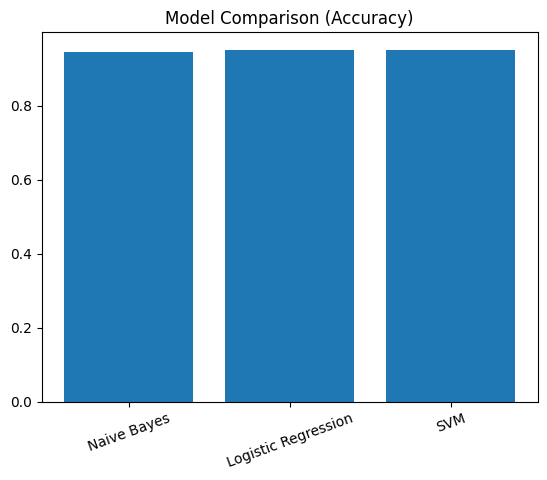

In [21]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Comparison (Accuracy)")
plt.xticks(rotation=20)
plt.show()

9. Confusion Matrix (Best Model)

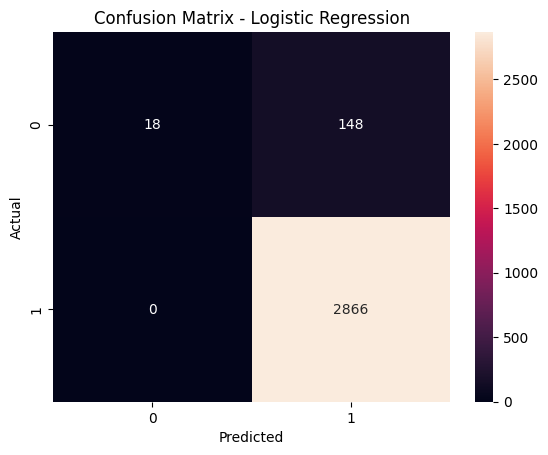

In [22]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

10. Cross Validation

In [23]:
print("Cross Validation (5-fold)")

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: Mean Accuracy = {scores.mean():.4f}")

Cross Validation (5-fold)
Naive Bayes: Mean Accuracy = 0.9429


Logistic Regression: Mean Accuracy = 0.9503
SVM: Mean Accuracy = 0.9487


11. Error Analysis

In [24]:
df_test = df_test.copy()
df_test['pred'] = y_pred_best

errors = df_test[df_test['label'] != df_test['pred']]

print("Example misclassified reviews:")
print(errors[['review_body', 'label', 'pred']].head(5))


Example misclassified reviews:
                                             review_body  label  pred
9882   อาหารบอกเลยว่าราคาตามเรทร้านอาหารเกาหลีเลย รสช...      0     1
14960  ดูจากหน้าร้าน คนเยอะมาก พนักงานบริการดี\nแต่อา...      0     1
12249  ร้านนี้ ถูกกกกก มาก เวลาใครใส่บาตรหรือตื่นเช้า...      0     1
11765  1人分のカレーは20〜30分くらいかかって、店のなかの満員に誰もたべてない時点に待ってみたら...      0     1
14459  ร้านเย็นตาโฟที่หารีวิวมาจากพันทิปเกี่ยวกับร้าน...      0     1
